# Python e API

### O que é uma API?

- É um conjunto de códigos para usar um serviço/site/aplicativo específico. Cada site/ferramenta tem sua própria API. É importante que você saiba ler as APIs que precisar para saber usar

- Um dos padrões mais comuns em API é pegar informações em formato json, uma espécie de dicionário que precisa ser tratada no Python para podermos analisar

- As possibilidades de API são infinitas, vamos fazer 2 exemplos aqui: Cotação de Moedas e Envio de SMS.

- Sites como Google, Youtube, Facebook, Twitter, ArcGis e praticamente qualquer ferramenta/site grande tem uma API.

### O que precisamos:

- Quase sempre você precisa de uma conta para consumir uma API. Algumas APIs são abertas, como a https://docs.awesomeapi.com.br/api-de-moedas , mas em muitos casos (como veremos no caso do SMS) vamos precisar ter uma conta ativa para consumir a API

- A Documentação da API (ou exemplos da internet) é a chave para conseguir usar uma API 

In [11]:
import requests
import json

cotacoes = requests.get('https://economia.awesomeapi.com.br/json/all')

cotacoes_dir = cotacoes.json()

print(cotacoes)
print(cotacoes_dir)



<Response [200]>
{'USD': {'code': 'USD', 'codein': 'BRL', 'name': 'Dólar Americano/Real Brasileiro', 'high': '5.329', 'low': '5.32157', 'varBid': '-0.0011', 'pctChange': '-0.02064', 'bid': '5.3278', 'ask': '5.3308', 'timestamp': '1759363722', 'create_date': '2025-10-01 21:08:42'}, 'USDT': {'code': 'USD', 'codein': 'BRLT', 'name': 'Dólar Americano/Real Brasileiro Turismo', 'high': '5.36715', 'low': '5.35966', 'varBid': '-0.00111', 'pctChange': '-0.020685', 'bid': '5.36594', 'ask': '5.53192', 'timestamp': '1759363723', 'create_date': '2025-10-01 21:08:43'}, 'CAD': {'code': 'CAD', 'codein': 'BRL', 'name': 'Dólar Canadense/Real Brasileiro', 'high': '3.81985', 'low': '3.81694', 'varBid': '0.001795', 'pctChange': '0.047016', 'bid': '3.81985', 'ask': '3.82941', 'timestamp': '1759363595', 'create_date': '2025-10-01 21:06:35'}, 'GBP': {'code': 'GBP', 'codein': 'BRL', 'name': 'Libra Esterlina/Real Brasileiro', 'high': '7.18292', 'low': '7.16846', 'varBid': '-0.004145', 'pctChange': '-0.057706', 

5.78695


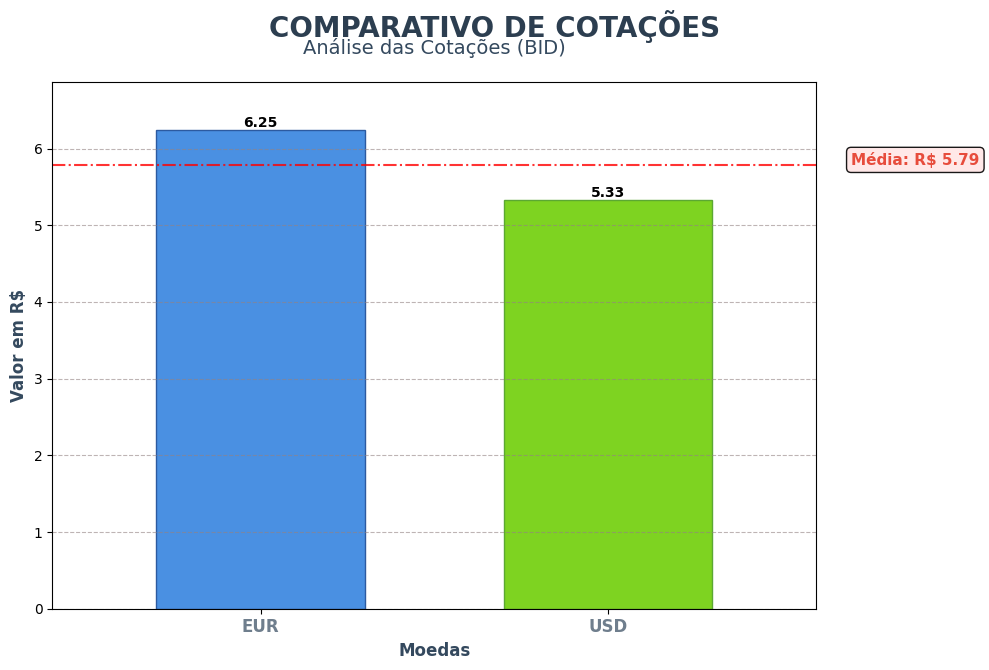

In [12]:
import matplotlib.pyplot as plt
import pandas as pd


df = pd.DataFrame(cotacoes_dir).T

colunas_numericas = [ 'high', 'low', 'bid', 'ask']
for coluna in colunas_numericas:
    df[coluna] = df[coluna].astype(float)

moedas = [ 'EUR', 'USD']
valores = [df.loc[m, 'bid'] for m in moedas]
media = sum(valores) / len(moedas)
print(media)

# Criação da figura e eixos
plt.subplots(figsize=(10, 7))

cores = ['#4a90e2', '#7ed321']  # Azul moderno e verde vibrante
cores_escuras = ['#2c5aa0', '#5ba832']  # Versões mais escuras para bordas


# Barras com cores personalizadas
bars = plt.bar(moedas, valores, color=cores, edgecolor=cores_escuras, width=0.6)

# Adiciona rótulos automáticos (com 2 casas decimais)
plt.bar_label(bars, fmt='%.2f', fontsize=10, weight='bold')




plt.axhline(y=media, color='red', linestyle='-.', alpha=0.8)
plt.text(len(valores) - 0.3,  (media) ,  f'Média: R$ {media:.2f}', 
         fontsize=11, 
         color='#e74c3c',           
         fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='#ffe6e6', alpha=0.9)
        )


# Título e rótulos dos eixos
plt.suptitle('COMPARATIVO DE COTAÇÕES', fontsize=20, fontweight='bold', 
             color='#2c3e50', y=0.95)

plt.title('Análise das Cotações (BID)', 
          fontsize=14, color='#34495e', pad=20)

plt.ylabel('Valor em R$', fontsize=12, color='#34495e', fontweight='bold')
plt.xlabel('Moedas', fontsize=12, color='#34495e', fontweight='bold')

plt.xticks(fontsize=12, color="#34495eb5", fontweight='bold')
# Grade horizontal suave para facilitar leitura
plt.grid(axis='y', linestyle='--', alpha=0.6, color = "#948282")

plt.ylim(0, max(valores) * 1.1)
margin = 0.1
plt.xlim(-0.5 - margin, len(moedas) - 0.5 + margin)

plt.savefig('grafico.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


In [ ]:
print(cotacoes_dir['BTC']['low'])


btc_ultimos_30_dias = requests.get('https://economia.awesomeapi.com.br/json/daily/BTC-BRL/30')
btc_ultimos_30_dias = btc_ultimos_30_dias.json()

display(btc_ultimos_30_dias)

607436


[{'code': 'BTC',
  'codein': 'BRL',
  'name': 'Bitcoin/Real Brasileiro',
  'high': '636165',
  'low': '607436',
  'varBid': '26366',
  'pctChange': '4.332',
  'bid': '634876',
  'ask': '634877',
  'timestamp': '1759363932',
  'create_date': '2025-10-01 21:12:12'},
 {'high': '632231',
  'low': '607436',
  'varBid': '24187',
  'pctChange': '3.98',
  'bid': '632121',
  'ask': '632122',
  'timestamp': '1759363196'},
 {'high': '611599',
  'low': '599701',
  'varBid': '-1256',
  'pctChange': '-0.206',
  'bid': '607675',
  'ask': '607676',
  'timestamp': '1759276771'},
 {'high': '610916',
  'low': '596316',
  'varBid': '7381',
  'pctChange': '1.227',
  'bid': '608889',
  'ask': '608890',
  'timestamp': '1759190382'},
 {'high': '602827',
  'low': '586609',
  'varBid': '12517',
  'pctChange': '2.126',
  'bid': '601550',
  'ask': '601551',
  'timestamp': '1759103982'},
 {'high': '589631',
  'low': '585500',
  'varBid': '-296',
  'pctChange': '-0.05',
  'bid': '588808',
  'ask': '588809',
  'time